In [4]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

print("✅ Todo importado correctamente")

✅ Todo importado correctamente


In [5]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# ¿Cuántos sobrevivieron?
print(df['Survived'].value_counts())

# ¿Hay datos faltantes?
print("\nDatos faltantes:")
print(df.isnull().sum())

Survived
0    549
1    342
Name: count, dtype: int64

Datos faltantes:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
# Rellenar edades faltantes con la mediana
df['Age'] = df['Age'].fillna(df['Age'].median())

# Convertir 'Sex' a número (male=0, female=1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Seleccionar las columnas que usará el modelo
features = ['Pclass', 'Sex', 'Age', 'Fare']
X = df[features]
y = df['Survived']

print("✅ Datos listos")
print(X.head())

✅ Datos listos
   Pclass  Sex   Age     Fare
0       3    0  22.0   7.2500
1       1    1  38.0  71.2833
2       3    1  26.0   7.9250
3       1    1  35.0  53.1000
4       3    0  35.0   8.0500


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} pasajeros")
print(f"Prueba: {X_test.shape[0]} pasajeros")

Entrenamiento: 712 pasajeros
Prueba: 179 pasajeros


In [9]:
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)

print("✅ Modelo entrenado")

✅ Modelo entrenado


Precisión del modelo: 79.89%


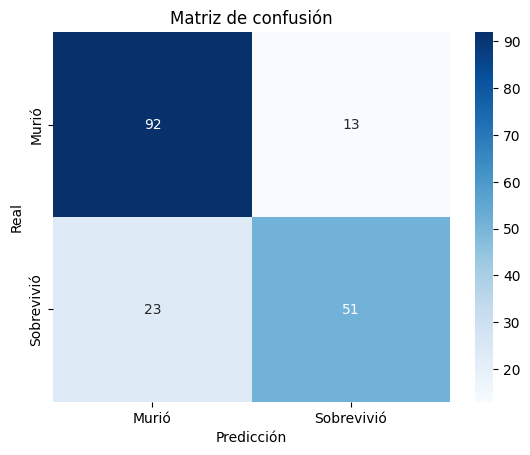

In [10]:
predicciones = modelo.predict(X_test)
precision = accuracy_score(y_test, predicciones)

print(f"Precisión del modelo: {precision:.2%}")

# Matriz de confusión
cm = confusion_matrix(y_test, predicciones)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Murió', 'Sobrevivió'],
            yticklabels=['Murió', 'Sobrevivió'])
plt.title('Matriz de confusión')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()